# 08b Visualize Ratio Sanity Check

`08-sanity_check_ratio.py` の保存結果を読み込んで、

```math
\frac{\phi_{\rm needed}}{\phi_{\rm amp,max}}
```

がなぜ小さいのかを 2 次元グラフで見る notebook です。

ここでは主に

- ratio そのもの
- `|A_unit(m_a)|`
- toy spectrum 側の寄与
- best mass での一覧

をまとめて確認します。
        


In [1]:
from pathlib import Path
import csv
from collections import defaultdict

import matplotlib.pyplot as plt
import numpy as np

ROOT = Path.cwd().resolve().parent
CSV_PATH = ROOT / "results/08-ratio-sanity-check/ratio_sanity_check.csv"


def read_csv(path):
    with path.open() as f:
        return list(csv.DictReader(f))


rows = read_csv(CSV_PATH)
case_rows = defaultdict(list)
for row in rows:
    case_rows[row["case_name"]].append(row)

case_names = sorted(case_rows)
case_names
        


['nphi_1_Lcut_800',
 'nphi_1_no_cut',
 'nphi_2_Lcut_800',
 'nphi_2_no_cut',
 'nphi_3_Lcut_800',
 'nphi_3_no_cut']

## ratio の全体像
        


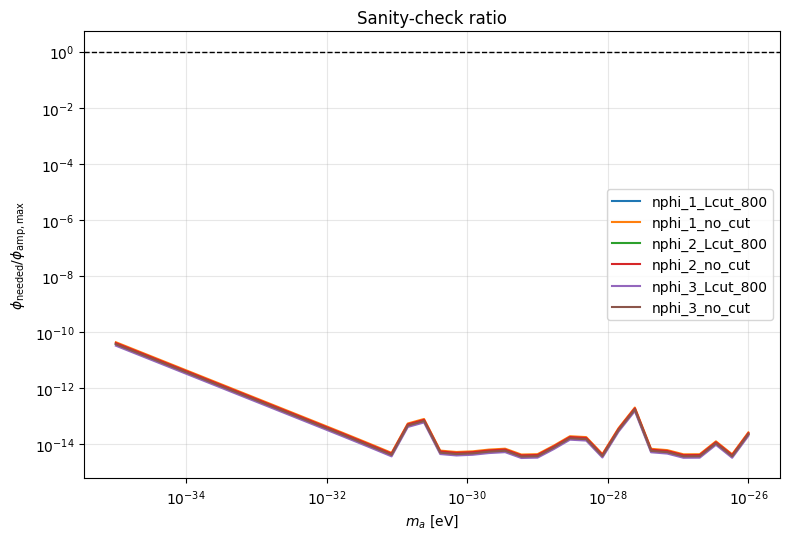

In [2]:
plt.figure(figsize=(8, 5.5))
plt.axhline(1.0, color="black", ls="--", lw=1.0)

for case_name in case_names:
    items = sorted(case_rows[case_name], key=lambda r: float(r["mass_eV"]))
    masses = np.array([float(r["mass_eV"]) for r in items])
    ratios = np.array([float(r["ratio_phi_needed_over_phi_amp_max"]) for r in items])
    plt.loglog(masses, ratios, label=case_name)

plt.xlabel(r"$m_a\ [{\rm eV}]$")
plt.ylabel(r"$\phi_{\rm needed}/\phi_{\rm amp,max}$")
plt.title(r"Sanity-check ratio")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()
        


## 内訳 1: `|A_unit(m_a)|`
        


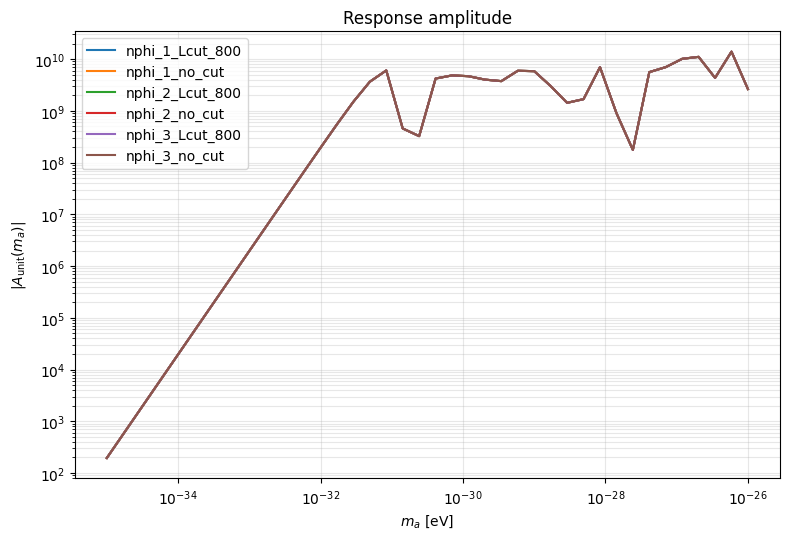

In [3]:
plt.figure(figsize=(8, 5.5))

for case_name in case_names:
    items = sorted(case_rows[case_name], key=lambda r: float(r["mass_eV"]))
    masses = np.array([float(r["mass_eV"]) for r in items])
    a_abs = np.array([float(r["A_unit_abs"]) for r in items])
    plt.loglog(masses, a_abs, label=case_name)

plt.xlabel(r"$m_a\ [{\rm eV}]$")
plt.ylabel(r"$|A_{\rm unit}(m_a)|$")
plt.title(r"Response amplitude")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()
        


## 内訳 2: toy spectrum 側の寄与

`08` では

```math
R_{\tau,\max}^{unit}
=
A_{\rm unit}^2 \times \max_L\left(\frac{C_L^{\tau\tau}}{C_L^{\phi\phi}}\right)
```

と見ているので、ここでは後者の

```math
\sqrt{\max_L(C_L^{\tau\tau}/C_L^{\phi\phi})}
```

を表示します。
        


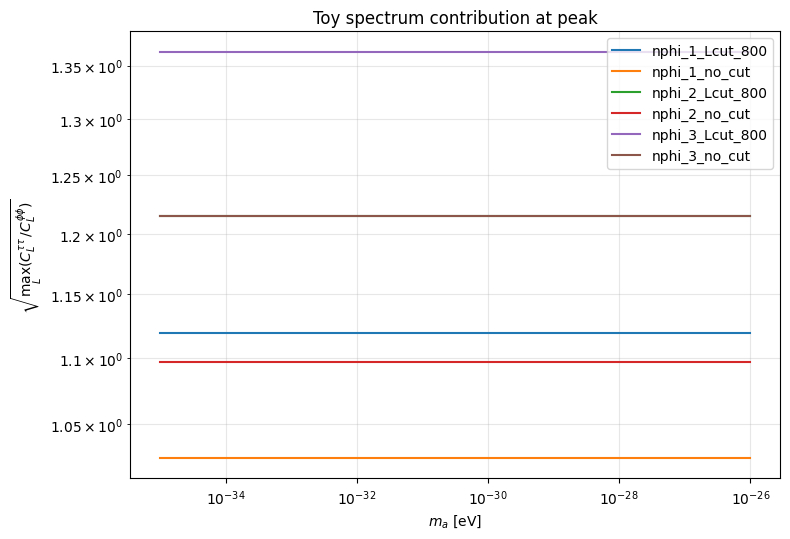

In [4]:
plt.figure(figsize=(8, 5.5))

for case_name in case_names:
    items = sorted(case_rows[case_name], key=lambda r: float(r["mass_eV"]))
    masses = np.array([float(r["mass_eV"]) for r in items])
    sqrt_spec = np.array([float(r["sqrt_spectrum_ratio_at_peak"]) for r in items])
    plt.loglog(masses, sqrt_spec, label=case_name)

plt.xlabel(r"$m_a\ [{\rm eV}]$")
plt.ylabel(r"$\sqrt{\max_L(C_L^{\tau\tau}/C_L^{\phi\phi})}$")
plt.title(r"Toy spectrum contribution at peak")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()
        


## best mass での summary
        


In [5]:
summary = []
for case_name in case_names:
    items = case_rows[case_name]
    best = max(items, key=lambda r: float(r["Rtau_max_unit"]))
    summary.append(
        {
            "case": case_name,
            "m_best_eV": float(best["mass_eV"]),
            "A_unit_abs": float(best["A_unit_abs"]),
            "sqrt_spec_ratio": float(best["sqrt_spectrum_ratio_at_peak"]),
            "phi_needed": float(best["phi_needed"]),
            "phi_amp_max": float(best["phi_amp_max"]),
            "ratio": float(best["ratio_phi_needed_over_phi_amp_max"]),
        }
    )

summary
        


[{'case': 'nphi_1_Lcut_800',
  'm_best_eV': 5.878016072274924e-27,
  'A_unit_abs': 13935403275.476799,
  'sqrt_spec_ratio': 1.1195133382730187,
  'phi_needed': 6.4098990004064e-11,
  'phi_amp_max': 15748.702119865331,
  'ratio': 4.07011254109695e-15},
 {'case': 'nphi_1_no_cut',
  'm_best_eV': 5.878016072274924e-27,
  'A_unit_abs': 13935403275.476799,
  'sqrt_spec_ratio': 1.0254741488776837,
  'phi_needed': 6.997706803034962e-11,
  'phi_amp_max': 15748.702119865331,
  'ratio': 4.443354601397973e-15},
 {'case': 'nphi_2_Lcut_800',
  'm_best_eV': 5.878016072274924e-27,
  'A_unit_abs': 13935403275.476799,
  'sqrt_spec_ratio': 1.2148297988697498,
  'phi_needed': 5.90697349918006e-11,
  'phi_amp_max': 15748.702119865331,
  'ratio': 3.750768446962391e-15},
 {'case': 'nphi_2_no_cut',
  'm_best_eV': 5.878016072274924e-27,
  'A_unit_abs': 13935403275.476799,
  'sqrt_spec_ratio': 1.0971854908487835,
  'phi_needed': 6.540341161808949e-11,
  'phi_amp_max': 15748.702119865331,
  'ratio': 4.1529397864